
<br>

Many of scikit-learn's evaluation metrics have multi-class capabilities, but for the deep learning part of the class we'll use torchmetrics. [torchmetrics](https://lightning.ai/docs/torchmetrics/stable/) is a library designed to simplify the computation of evaluation metrics in PyTorch. It is optimized for efficient computation on both CPUs and GPUs and supports metrics across different tasks, including classification, regression and object detection. For multiclass classification tasks, torchmetrics provides metrics for all the usual suspects such as accuracy, precision, recall, F1-score and the confusion matrix.

We begin by generating or model predictions against the final test set. `yactual` represent the actual test set labels, and `yhat` our model's class predictions based on the index of the maximum value per sample. 


In [11]:

yactual = []
yhat = []

for Xtest, ytest in test_loader:

    # Get model class predictions.
    ypred = model(Xtest).argmax(dim=1)

    # Add actual labels to yact.
    yactual.append(ytest)

    # Add predicted labels to yhat.
    yhat.append(ypred)


# Combine yactual and yhat into single tensors.
targets = torch.cat(yactual)
preds = torch.cat(yhat)

print(f"type(targets): {type(targets)}")
print(f"type(preds)  : {type(preds)}")
print(f"targets.shape: {targets.shape}")
print(f"preds.shape  : {preds.shape}")



type(targets): <class 'torch.Tensor'>
type(preds)  : <class 'torch.Tensor'>
targets.shape: torch.Size([1000])
preds.shape  : torch.Size([1000])



#### **Accuracy**

In [13]:

import torchmetrics

metric = torchmetrics.Accuracy(task="multiclass", num_classes=10)
acc = metric(preds, targets)
print(f"Accuracy: {acc:.4f}")



Accuracy: 0.9720



#### **Precision**

In [14]:

metric = torchmetrics.Precision(task="multiclass", num_classes=10, average="macro")
pr = metric(preds, targets)
print(f"Precision: {pr:.4f}")


Precision: 0.9723



#### **Recall**


In [15]:

metric = torchmetrics.Recall(task="multiclass", num_classes=10, average="macro")
rec = metric(preds, targets)
print(f"Recall: {rec:.4f}")


Recall: 0.9725



#### **F1-score**

In [16]:

metric = torchmetrics.F1Score(task="multiclass", num_classes=10, average="macro")
f1 = metric(preds, targets)
print(f"F1 Score: {f1:.4f}")


F1 Score: 0.9719



#### **Multiclass Confusion Matrix**

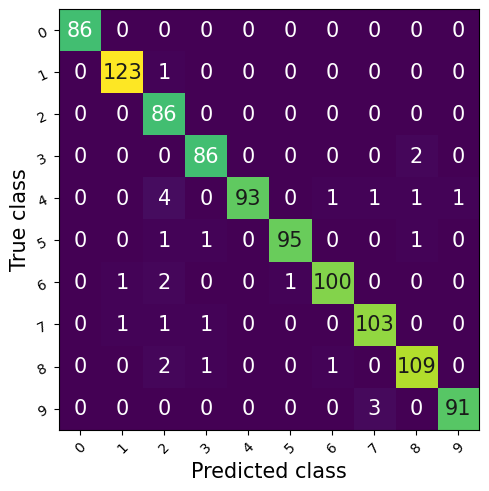

In [17]:

from torchmetrics.classification import MulticlassConfusionMatrix

cm = MulticlassConfusionMatrix(num_classes=10)
cm.update(preds, targets)
fig_, ax_ = cm.plot()
